# Análisis de correlaciones de features

Exploramos las correlaciones entre las métricas featurizadas y el resultado binario `WL_NUM` agrupando las señales en bloques `baseline`, `venue` y `enhanced` tal como en `02_WL_estimator`.
El objetivo es cuantificar la aportación de cada grupo y comparar su potencia predictiva de forma consistente.

In [7]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

sns.set_theme(style='whitegrid')

In [8]:
FEATURIZED_PATH = "/Users/pablo/Documents/BigData/BasketballAnalysis/00_data/00d_featurized/2024-25/teamgamelogs_featurized.parquet"
TARGET_COLUMN = 'WL_NUM'


In [9]:
df = pd.read_parquet(FEATURIZED_PATH)
if TARGET_COLUMN not in df.columns:
    raise KeyError(f'No se encontró la columna objetivo {TARGET_COLUMN!r} en el dataset featurizado.')

numeric_df = df.select_dtypes(include=[np.number]).copy()
print(f'Filas: {len(numeric_df)} | Columnas numéricas: {numeric_df.shape[1]}')


Filas: 2639 | Columnas numéricas: 86


In [10]:
# DEFINIR GRUPOS EXACTOS (CORREGIDOS según WL_estimator)
FEATURE_GROUPS = {
    'baseline': [
        'FG_PCT', 'FT_PCT', 'FG3_PCT', 'REB', 'AST', 'TOV', 'PLUS_MINUS',
        'OFF_RATING', 'DEF_RATING', 'NET_RATING', 'E_OFF_RATING', 'E_DEF_RATING', 'E_NET_RATING',
        'ROLL10_FG_PCT', 'ROLL10_FT_PCT', 'ROLL10_FG3_PCT', 'ROLL10_REB', 'ROLL10_AST', 'ROLL10_TOV',
        'ROLL10_PLUS_MINUS', 'ROLL10_OFF_RATING', 'ROLL10_DEF_RATING', 'ROLL10_NET_RATING',
        'ROLL10_E_OFF_RATING', 'ROLL10_E_DEF_RATING', 'ROLL10_E_NET_RATING'
    ],
    'venue': [
        'VENUE_HOME_W_PCT', 'VENUE_ROAD_W_PCT'
    ],
    'enhanced': [
        'WIN_STREAK', 'LAST_5_PCT', 'DAYS_REST', 'SEASON_W_PCT', 'PACE', 'TURNOVER_RATIO', 'BACK_TO_BACK_FLAG',
        'REST_BUCKET_GP', 'REST_BUCKET_PLUS_MINUS', 'REST_BUCKET_POINTS', 'REST_BUCKET_WIN_PCT'
    ]
}

def get_available_features(df, feature_list):
    '''Filtra solo las features que existen en el DataFrame.'''
    available = [f for f in feature_list if f in df.columns]
    missing = [f for f in feature_list if f not in df.columns]
    if missing:
        print(f"⚠️ Features faltantes en {df.shape} dataset: {missing}")
    return available

Top 10 correlaciones positivas


,Correlación
VENUE_ROAD_W_PCT,0.278556
VENUE_HOME_W_PCT,0.277642
ROLL10_PLUS_MINUS,0.236103
SEASON_W_PCT,0.200219
ROLL10_E_NET_RATING,0.197147
ROLL10_NET_RATING,0.197147
LAST_5_PCT,0.188821
WIN_STREAK,0.134676
ROLL10_FG_PCT,0.127844
ROLL10_OFF_RATING,0.119195


Top 10 correlaciones negativas


,Correlación
ROLL10_OPP_PTS_OFF_TOV,-0.168002
ROLL10_USG_PCT,-0.141928
ROLL10_E_DEF_RATING,-0.140650
ROLL10_DEF_RATING,-0.140650
ROLL10_TOV,-0.139862
ROLL10_OPP_PTS_FB,-0.134691
ROLL10_PCT_FTM,-0.133921
ROLL10_PCT_FTA,-0.133269
ROLL10_PCT_FGA,-0.116115
ROLL10_PCT_FGA_2PT,-0.115397


5 correlaciones más débiles (en valor absoluto)


,|Correlación|
ROLL10_FTA,0.003496
ROLL10_BLK,0.005692
ROLL10_PACE,0.005811
ROLL10_E_PACE,0.005811
PACE,0.005811


## Funciones de análisis por grupos

Definimos utilidades para validar features disponibles, analizar correlaciones dentro de cada bloque y comparar resultados entre grupos corregidos.

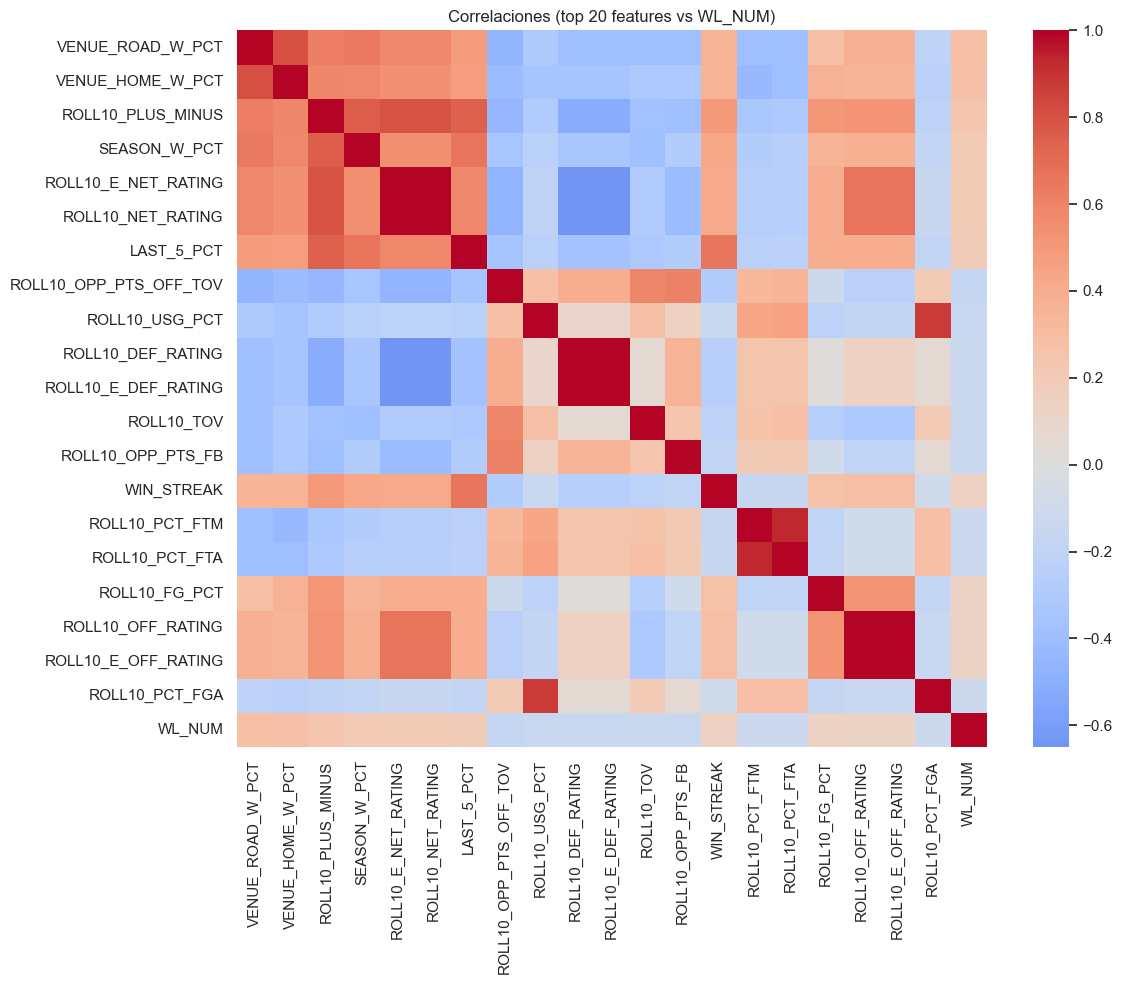

In [11]:
def analyze_group_correlations(df, group_name, target='WL_NUM'):
    '''Analiza correlaciones para un grupo específico.'''
    features = get_available_features(df, FEATURE_GROUPS[group_name])

    if not features:
        print(f"❌ No features disponibles para grupo: {group_name}")
        return None

    print(f"📊 Analizando {len(features)} features del grupo: {group_name}")

    corr_with_target = df[features + [target]].corr()[target].drop(target)
    valid_corrs = corr_with_target.dropna()

    if len(valid_corrs) == 0:
        print(f"❌ No hay correlaciones válidas para {group_name}")
        return None

    top_pos = valid_corrs.sort_values(ascending=False).head(10)
    top_neg = valid_corrs.sort_values().head(10)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

    group_data = df[features + [target]]
    corr_matrix = group_data.corr()

    sns.heatmap(
        corr_matrix, annot=False, cmap='coolwarm', center=0, ax=ax1, cbar_kws={'shrink': 0.8}
    )
    ax1.set_title(f"Matriz Correlaciones - {group_name.upper()}\n({len(features)} features)")

    plot_corrs = valid_corrs.sort_values(ascending=False).head(15)
    colors = ['green' if x > 0 else 'red' for x in plot_corrs]

    y_pos = np.arange(len(plot_corrs))
    ax2.barh(y_pos, plot_corrs.values, color=colors, alpha=0.7)
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(plot_corrs.index, fontsize=9)
    ax2.axvline(x=0, color='black', linewidth=0.8)
    ax2.set_xlabel('Correlación con WL_NUM')
    ax2.set_title(f"Top 15 Correlaciones - {group_name.upper()}")

    for i, v in enumerate(plot_corrs.values):
        ax2.text(
            v + (0.01 if v > 0 else -0.03),
            i,
            f"{v:.3f}",
            color='black',
            fontsize=8,
            va='center',
            ha='left' if v > 0 else 'right'
        )

    plt.tight_layout()
    plt.show()

    print(f"\n🎯 TOP 10 POSITIVAS - {group_name.upper()}:")
    display(top_pos.to_frame('Correlación'))

    print(f"\n📉 TOP 10 NEGATIVAS - {group_name.upper()}:")
    display(top_neg.to_frame('Correlación'))

    print(f"\n📈 ESTADÍSTICAS {group_name.upper()}:")
    print(f"   • Features analizadas: {len(valid_corrs)}")
    print(f"   • Correlación máxima: {valid_corrs.abs().max():.3f}")
    print(f"   • Correlación promedio (abs): {valid_corrs.abs().mean():.3f}")

    return {
        'group': group_name,
        'features': features,
        'correlations': valid_corrs,
        'top_positive': top_pos,
        'top_negative': top_neg,
    }


def compare_all_groups(df, target='WL_NUM'):
    '''Compara potencia predictiva entre los 3 grupos.'''
    print('🔍 INICIANDO ANÁLISIS COMPARATIVO ENTRE GRUPOS')
    print('=' * 70)

    results = {}
    comparison_data = []

    for group_name in ['baseline', 'venue', 'enhanced']:
        print(f"\n📋 ANALIZANDO GRUPO: {group_name.upper()}")
        print('-' * 50)

        result = analyze_group_correlations(df, group_name, target)
        if result:
            results[group_name] = result

            corrs = result['correlations']
            if len(corrs) > 0:
                comparison_data.append({
                    'Grupo': group_name.upper(),
                    'Max_Corr_Abs': corrs.abs().max(),
                    'Mean_Corr_Abs': corrs.abs().mean(),
                    'N_Features': len(corrs),
                    'Top_Feature': corrs.abs().idxmax(),
                    'Top_Value': corrs.abs().max(),
                })

    if comparison_data:
        comparison_df = pd.DataFrame(comparison_data)
        print(f"\n🏆 COMPARACIÓN ENTRE GRUPOS:")
        print('=' * 70)
        display(comparison_df.sort_values('Max_Corr_Abs', ascending=False))

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

        groups = [x['Grupo'] for x in comparison_data]
        max_corrs = [x['Max_Corr_Abs'] for x in comparison_data]
        mean_corrs = [x['Mean_Corr_Abs'] for x in comparison_data]

        bars1 = ax1.bar(groups, max_corrs, color=['#1f77b4', '#ff7f0e', '#2ca02c'], alpha=0.7)
        ax1.set_title('Máxima Correlación Absoluta por Grupo')
        ax1.set_ylabel('Correlación (absoluta)')

        for bar, value in zip(bars1, max_corrs):
            ax1.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f"{value:.3f}",
                ha='center',
                va='bottom',
                fontweight='bold'
            )

        bars2 = ax2.bar(groups, mean_corrs, color=['#1f77b4', '#ff7f0e', '#2ca02c'], alpha=0.7)
        ax2.set_title('Correlación Promedio (absoluta) por Grupo')
        ax2.set_ylabel('Correlación Promedio (abs)')

        for bar, value in zip(bars2, mean_corrs):
            ax2.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f"{value:.3f}",
                ha='center',
                va='bottom'
            )

        plt.tight_layout()
        plt.show()

    return results


def test_custom_combination(df, features_list, combination_name='CUSTOM', target='WL_NUM'):
    '''Para probar rápidamente combinaciones específicas de features.'''
    print(f"🧪 TESTING COMBINACIÓN: {combination_name}")
    print('=' * 60)

    available_features = get_available_features(df, features_list)

    if not available_features:
        print('❌ No hay features disponibles para testing')
        return None

    print(f"Features incluidas ({len(available_features)}):")
    for feat in available_features:
        print(f"  • {feat}")

    corr_data = df[available_features + [target]]
    corr_with_target = corr_data.corr()[target].drop(target)
    valid_corrs = corr_with_target.dropna().sort_values(ascending=False)

    print(f"\n📊 RESULTADOS {combination_name}:")
    print(f"Top 5 positivas: {valid_corrs.head(5).to_dict()}")
    print(f"Correlación máxima: {valid_corrs.abs().max():.3f}")

    return valid_corrs


## Ejecución del análisis estructurado

Se realiza el análisis individual de cada grupo, la comparación agregada y pruebas rápidas de combinaciones reales de variables.

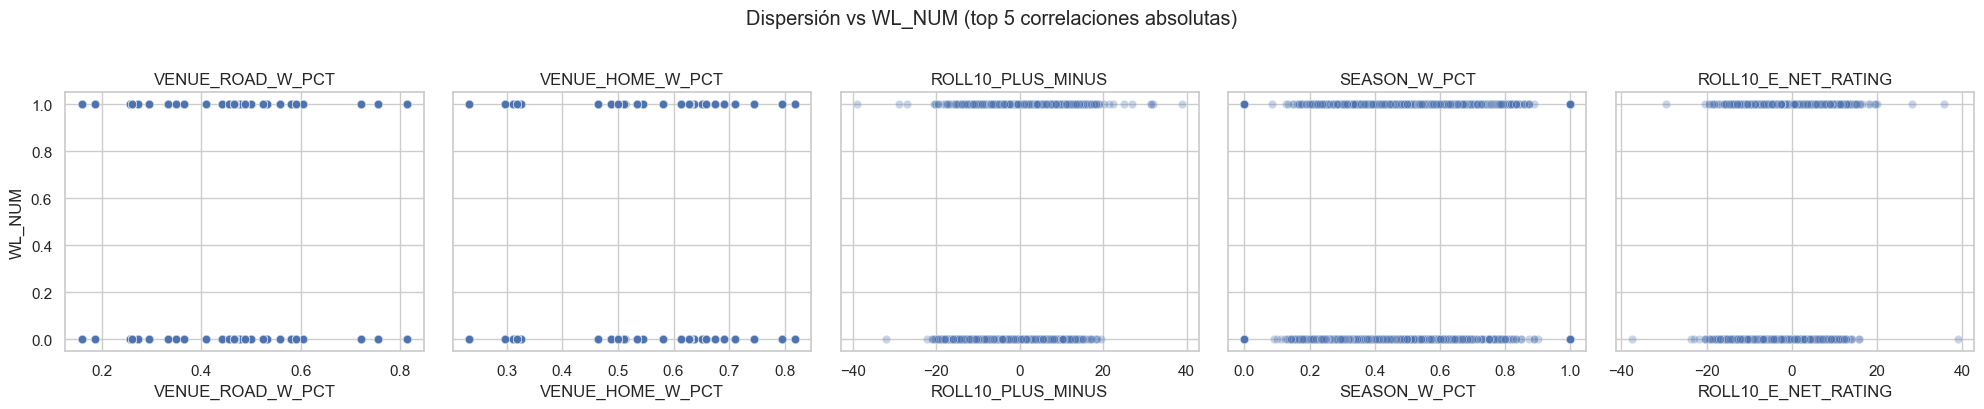

In [12]:
# 1. Análisis individual de cada grupo
print('🎯 ANÁLISIS INDIVIDUAL POR GRUPOS')
baseline_results = analyze_group_correlations(df, 'baseline', target=TARGET_COLUMN)
venue_results = analyze_group_correlations(df, 'venue', target=TARGET_COLUMN)
enhanced_results = analyze_group_correlations(df, 'enhanced', target=TARGET_COLUMN)

# 2. Comparación entre grupos
print('\n🔬 COMPARACIÓN ENTRE GRUPOS')
all_results = compare_all_groups(df, target=TARGET_COLUMN)

# 3. Ejemplos de testing rápido con combinaciones reales
print('\n🚀 TESTING RÁPIDO DE COMBINACIONES')
best_singles = ['VENUE_HOME_W_PCT', 'ROLL10_PLUS_MINUS', 'SEASON_W_PCT', 'LAST_5_PCT']
test_custom_combination(df, best_singles, 'MEJORES INDIVIDUALES', target=TARGET_COLUMN)

combo_baseline_venue = FEATURE_GROUPS['baseline'] + FEATURE_GROUPS['venue']
test_custom_combination(df, combo_baseline_venue, 'BASELINE + VENUE', target=TARGET_COLUMN)

all_features = FEATURE_GROUPS['baseline'] + FEATURE_GROUPS['venue'] + FEATURE_GROUPS['enhanced']
test_custom_combination(df, all_features, 'TODAS LAS FEATURES', target=TARGET_COLUMN)

rest_features = [f for f in FEATURE_GROUPS['enhanced'] if 'REST' in f or 'DAYS' in f]
test_custom_combination(df, rest_features, 'SOLO FEATURES DESCANSO', target=TARGET_COLUMN)
